In [247]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [248]:
data=pd.read_csv("exoplanet_data.csv", comment ="#")
df=pd.DataFrame(data)

In [249]:
df.shape #There are 583 rows and 92 columns

(583, 92)

In [250]:
print(df.columns)
#pl_orbsmaxerr1, st_tefferr2, sy_snum, pl_radj, sy_kmag

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [251]:
#Table Label, Database Column Name, Description of Parameter, my description:

#Planet Name, pl_name, "Planet name most commonly used in the literature", the name that is most popular. 
#Host Name, hostname, "Stellar name most commonly used in the literature", the name of the star that hosts the planet that is most popular
#Discovery Method, discoverymethod, "Method by which the planet was first identified", the way the planet was found.
#Spectral Type, st_spectype, "Classification of the star based on their spectral characteristics following the Morgan-Keenan system", classifying the star accoriding to the established system.
#Equilibrium Temperature [K], pl_eqt, "The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body", the temperature of the planet.
#Planet Mass or Mass*sin(i) [Jupiter Mass], pl_bmassj , "Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses", the mass of the planet using Jupiter as a scale.
df= df[['pl_name', 'hostname','discoverymethod','pl_eqt', 'st_spectype', 'pl_bmassj']]
df

,pl_name,hostname,discoverymethod,pl_eqt,st_spectype,pl_bmassj
0,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.912000
1,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.870000
2,DMPP-1 b,DMPP-1,Radial Velocity,NaN,NaN,0.052859
3,DMPP-1 b,DMPP-1,Radial Velocity,877.0,F8 V,0.076362
4,DMPP-1 c,DMPP-1,Radial Velocity,NaN,NaN,0.034421
...,...,...,...,...,...,...
578,bet Pic c,bet Pic,Radial Velocity,1250.0,NaN,8.200000
579,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,10.139000
580,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,9.000000
581,eps Ind A b,eps Ind A,Radial Velocity,275.0,K5 V,6.310000


In [252]:
df= df.dropna()

In [253]:
df.shape #There are now 70 rows and 6 columns

(70, 6)

In [254]:
df.head()

,pl_name,hostname,discoverymethod,pl_eqt,st_spectype,pl_bmassj
3,DMPP-1 b,DMPP-1,Radial Velocity,877.0,F8 V,0.076362
5,DMPP-1 c,DMPP-1,Radial Velocity,1239.0,F8 V,0.030205
7,DMPP-1 d,DMPP-1,Radial Velocity,1632.0,F8 V,0.010540
8,DMPP-1 e,DMPP-1,Radial Velocity,1314.0,F8 V,0.012994
10,DMPP-2 b,DMPP-2,Radial Velocity,1000.0,F5 V,0.437000


In [255]:
df.tail()

,pl_name,hostname,discoverymethod,pl_eqt,st_spectype,pl_bmassj
562,WASP-185 b,WASP-185,Transit,1160.0,G0 V,0.980
565,WASP-190 b,WASP-190,Transit,1500.0,F6 IV-V,1.000
569,WASP-192 b,WASP-192,Transit,1620.0,G0 V,2.300
572,XO-7 b,XO-7,Transit,1743.0,G0 V,0.709
581,eps Ind A b,eps Ind A,Radial Velocity,275.0,K5 V,6.310


In [256]:
print(df.columns)

Index(['pl_name', 'hostname', 'discoverymethod', 'pl_eqt', 'st_spectype',
       'pl_bmassj'],
      dtype='object')


In [257]:
#4.4 Analyze Data

In [258]:
df['discoverymethod'].value_counts()

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

In [259]:
#There is the transit, radial velocity, and imaging discovery methods
#In trasit, there are 71. 13 in Radial Velocity. 2 in Imaging.
#Transit: This method discovers a planet when it passes by it's host star, this causes a dip in the star's brightness
#Radial Velocity: Known as the "wobble" method, this uses the gravitational pull by the planet on it's host star to detect the planet.
#Imaging: Photos are taken of the planet where the brightness is then tweaked in order to view the planet.

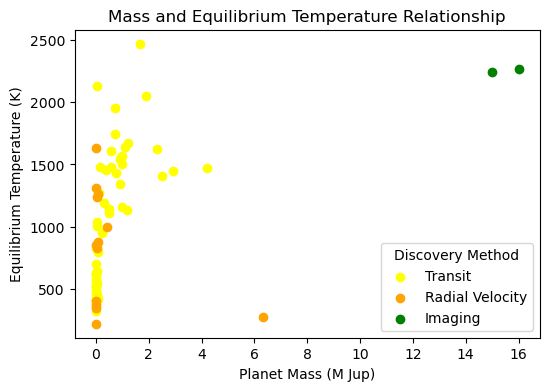

In [260]:
plt.figure(figsize=(6,4))
plt.xlabel("Planet Mass (M Jup)")
plt.ylabel("Equilibrium Temperature (K)")

colors = {'Transit':'yellow', 'Radial Velocity':'orange', 'Imaging':'green'}

for method, color in colors.items():
    plt.scatter(
      df.loc[df['discoverymethod']==method, 'pl_bmassj'],df.loc[df['discoverymethod']== method, 'pl_eqt'], color=color,label=method)
plt.legend(title="Discovery Method")
plt.title("Mass and Equilibrium Temperature Relationship")
plt.show() 

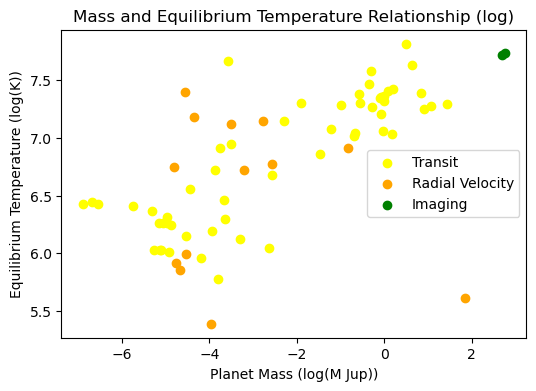

In [261]:
plt.figure(figsize=(6,4))
plt.xlabel("Planet Mass (log(M Jup))")
plt.ylabel("Equilibrium Temperature (log(K))")

colors = {'Transit':'yellow', 'Radial Velocity':'orange', 'Imaging':'green'}
for method, color in colors.items():
    plt.scatter(np.log(df.loc[df['discoverymethod'] == method, 'pl_bmassj']),np.log(df.loc[df['discoverymethod'] == method, 'pl_eqt']),color=color,label=method)
plt.legend()
plt.title("Mass and Equilibrium Temperature Relationship (log)")
plt.show() 

In [262]:
#Exoplanets found by the imaging method more likely to be massive 

In [263]:
mass_greaterthan5=df[df['pl_bmassj']>5]
coldest_planet=mass_greaterthan5['pl_eqt'].idxmin()
coldest_greatest=df.loc[coldest_planet]
print(coldest_greatest)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
pl_eqt                       275.0
st_spectype                   K5 V
pl_bmassj                     6.31
Name: 581, dtype: object


In [264]:
#Name:eps Ind A b
#Index:581
#equilibrium temperature:  275
#Mass (in Jupiter masses): 6.31
#It orbits a K-type star, since the sun is a G-type star they are pretty similar

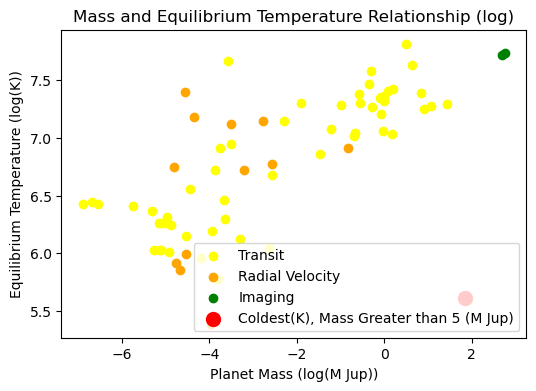

In [265]:
plt.figure(figsize=(6,4))
plt.xlabel("Planet Mass (log(M Jup))")
plt.ylabel("Equilibrium Temperature (log(K))")

colors = {'Transit':'yellow', 'Radial Velocity':'orange', 'Imaging':'green'}
for method, color in colors.items():
    plt.scatter(np.log(df.loc[df['discoverymethod'] == method, 'pl_bmassj']),np.log(df.loc[df['discoverymethod'] == method, 'pl_eqt']),color=color,label=method)

plt.scatter(np.log(coldest_greatest['pl_bmassj']), np.log(coldest_greatest['pl_eqt']), color="red", s=100, label="Coldest(K), Mass Greater than 5 (M Jup)")
plt.legend()
plt.title("Mass and Equilibrium Temperature Relationship (log)")
plt.show() 

In [266]:
#Nature Paper

#Title: "A temperate super-Jupiter imaged with JWST in the mid-infrared"
#Summary: There had been claims of a giant-planet, where it was found, but wuth 
#different properties to the ones claimed. The one they found is approximately 275K and very bright. 
#This fits with their observations as well. They refer to it as b.
#Yes, my answer matches with their exoplanet
#It defies expectations and much different than it's host planet
#It seems to be that the mass and temperatures match.
